# Extract, Transform, Load(EDA) 

In [1]:
# Importing modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

In [2]:
# Reading files
absent = pd.read_csv("./Absent_Data.csv")
compensation = pd.read_csv("./compensation.csv")
reasons = pd.read_csv("./Reasons.csv")

In [3]:
# Exploring data
absent.head()
absent.info()
compensation.info()
reasons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   ID                               740 non-null    int64 
 1   Reason for absence               740 non-null    int64 
 2   Month of absence                 740 non-null    int64 
 3   Day of the week                  740 non-null    int64 
 4   Seasons                          740 non-null    int64 
 5   Transportation expense           740 non-null    int64 
 6   Distance from Residence to Work  740 non-null    int64 
 7   Service time                     740 non-null    int64 
 8   Age                              740 non-null    int64 
 9   Work load Average/day            740 non-null    object
 10  Hit target                       740 non-null    int64 
 11  Disciplinary failure             740 non-null    int64 
 12  Education                        740

In [4]:
# Merging absent and compensation
merge1 = absent.merge(
    compensation,
    how = "inner",
    on="ID",
    validate="1:1"
)

In [5]:
# merging 1st merge with reasons
merge2 = merge1.merge(
    reasons,
    how="inner",
    left_on="Reason for absence",
    right_on="Number",
    indicator=True,
    validate="m:1"
)

In [6]:
# Exploring final merge
merge2.columns
merge2.head()

,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Work load Average/day,...,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours,comp/hr,Number,Reason,_merge
0,1,26,7,3,1,289,36,13,33,"239,554",...,0,1,90,172,30,4,35,26,unjustified absence,both
1,2,0,7,3,1,118,13,18,50,"239,554",...,0,0,98,178,31,0,49,0,Unkown,both
2,3,23,7,4,1,179,51,18,38,"239,554",...,0,0,89,170,31,2,47,23,medical consultation,both
3,4,7,7,5,1,279,5,14,39,"239,554",...,1,0,68,168,24,4,51,7,Diseases of the eye and adnexa,both
4,5,23,7,5,1,289,36,13,33,"239,554",...,0,1,90,172,30,2,25,23,medical consultation,both


# Finding Healthy Employees and Compensation per Year for Healthy Employees based on Company Budget

In [7]:
# Finding healthiest employees for the bonus
print(
    merge2[
        (merge2["Social drinker"] == 0) &
        (merge2["Social smoker"] == 0) &
        (merge2["Body mass index"].between(19,25)) &
        (merge2["Absenteeism time in hours"] < merge2["Absenteeism time in hours"].mean() )
    ].sort_values(["Body mass index", "Absenteeism time in hours", "ID"], ascending = [False, True, True]).head(10)
)

      ID  Reason for absence  Month of absence  Day of the week  Seasons  \
214  215                   0                 5                4        3   
325  326                   0                11                3        4   
715  716                   0                 6                2        3   
739  740                   0                 0                6        3   
152  153                  23                 2                3        2   
458  459                  11                 6                3        1   
617  618                  25                 2                6        2   
676  677                  28                 5                4        3   
698  699                  23                 5                5        3   
508  509                  11                10                5        4   

     Transportation expense  Distance from Residence to Work  Service time  \
214                     330                               16             4   
325    

In [8]:
# Defining compensation per year given total budget
def comp_per_year(budget):
    workers = merge2[merge2["Social smoker"] == 0]["ID"].count()
    return print("Total compensation per employee is " + str(round(budget/workers,2)))
comp_per_year(983221)

Total compensation per employee is 1433.27


# Adding BMI Category and Seasons columns

In [9]:
# Adding BMI category
conditions = [
    merge2["Body mass index"] < 18.5,
    merge2["Body mass index"].between(18.5, 25),
    merge2["Body mass index"].between(25, 30),
    merge2["Body mass index"] > 18.5
]
choices = ["Underweight", "Healthy", "Overweight", "Obese"]
merge2["BMI Category"] = np.select(conditions, choices, default="Unknown")

merge2["BMI Category"].value_counts() # Checking if it worked

# Adding Season
conditions = [
    merge2["Month of absence"].isin([12, 1, 2]),
    merge2["Month of absence"].isin([3, 4, 5]),
    merge2["Month of absence"].isin([6, 7, 8]),
    merge2["Month of absence"].isin([9, 10, 11])
]
choices = ["Winter", "Spring", "Summer", "Fall"]
merge2["Season Name"] = np.select(conditions, choices, default="Winter")

# Changing month name from 0 to 1
merge2.loc[merge2["Month of absence"] == 0, "Month of absence"] = 1

In [10]:
# Selecting relevant columns from original data
Final_Absent = merge2.loc[:,["ID", "Reason", 'Body mass index', 'BMI Category', "Season Name",
                             'Month of absence', 'Day of the week', 
                             'Transportation expense', 'Distance from Residence to Work',
                             'Education', 'Son', 'Social drinker', 'Social smoker', 'Pet',
                             'Disciplinary failure', 'Age', 'Absenteeism time in hours', 'comp/hr']]
Final_Absent.head() # Exploring final data

,ID,Reason,Body mass index,BMI Category,Season Name,Month of absence,Day of the week,Transportation expense,Distance from Residence to Work,Education,Son,Social drinker,Social smoker,Pet,Disciplinary failure,Age,Absenteeism time in hours,comp/hr
0,1,unjustified absence,30,Overweight,Summer,7,3,289,36,1,2,1,0,1,0,33,4,35
1,2,Unkown,31,Obese,Summer,7,3,118,13,1,1,1,0,0,1,50,0,49
2,3,medical consultation,31,Obese,Summer,7,4,179,51,1,0,1,0,0,0,38,2,47
3,4,Diseases of the eye and adnexa,24,Healthy,Summer,7,5,279,5,1,2,1,1,0,0,39,4,51
4,5,medical consultation,30,Overweight,Summer,7,5,289,36,1,2,1,0,1,0,33,2,25


# Exploratory Data Analysis (EDA)

## Part 1 - Checking KPIs

In [11]:
# EDA KPI
print("No of employees: " + str(Final_Absent['ID'].count()))
print("Average age: " + str(round(Final_Absent["Age"].mean())) + " Years")
print("Total Absent Time: " + str(Final_Absent["Absenteeism time in hours"].sum()) + " Hours")
print("Average time absent per employee: " +
      str(round(Final_Absent["Absenteeism time in hours"].mean(),2)) + " Hours")
print("Highest Hours Absent: " + str(Final_Absent["Absenteeism time in hours"].max()) + " Hours")
total_emp = Final_Absent['ID'].count()
tot_drink_smoke = Final_Absent[
                        (Final_Absent["Social smoker"] == 1) |
                        (Final_Absent["Social drinker"] == 1)
]["ID"].count()
print("Total drinker of smoker: " + str(round(tot_drink_smoke*100/total_emp,2)) + " %")

No of employees: 740
Average age: 36 Years
Total Absent Time: 5124 Hours
Average time absent per employee: 6.92 Hours
Highest Hours Absent: 120 Hours
Total drinker of smoker: 61.35 %


## Part 2 - Absenteeism Overview

In [12]:
# Top Reasons for being Absent
print(Final_Absent["Reason"].str.title().value_counts(sort = True).head(10))

Reason
Medical Consultation                                                   149
Dental Consultation                                                    112
Physiotherapy                                                           69
Diseases Of The Musculoskeletal System And Connective Tissue            55
Unkown                                                                  43
Injury, Poisoning And Certain Other Consequences Of External Causes     40
Patient Follow-Up                                                       38
Unjustified Absence                                                     33
Laboratory Examination                                                  31
Diseases Of The Digestive System                                        26
Name: count, dtype: int64


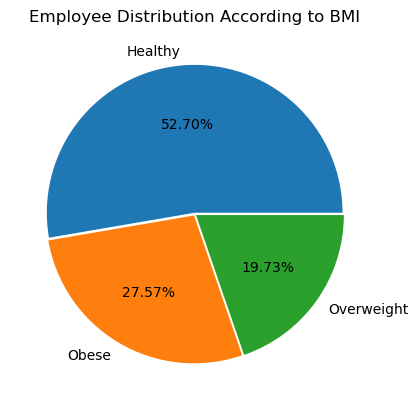

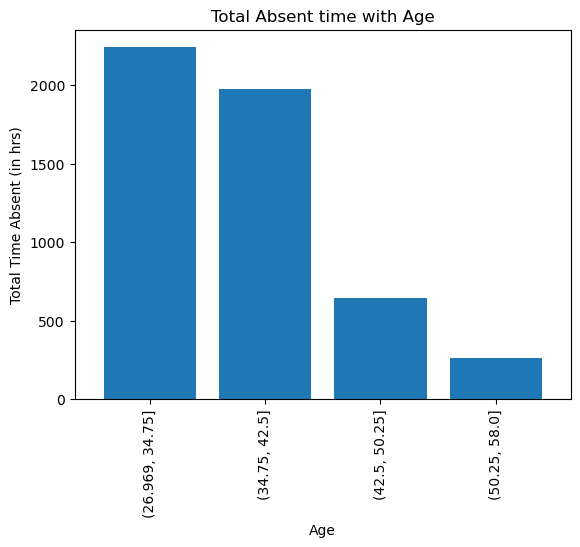

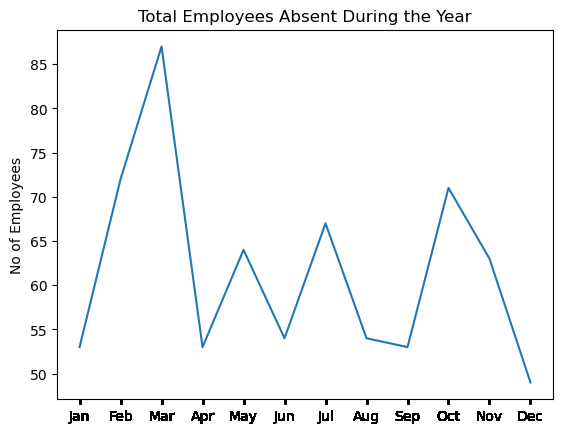

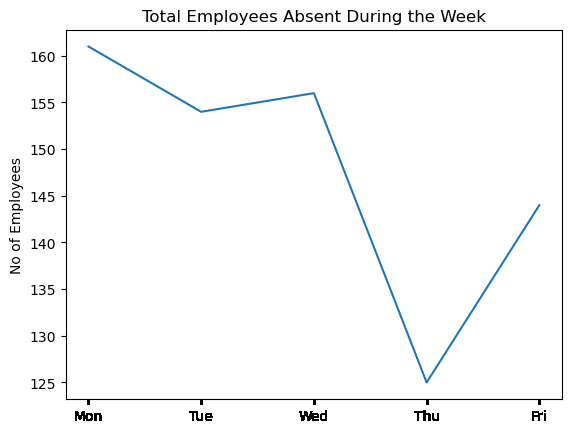

<Figure size 640x480 with 0 Axes>

In [13]:
# Employee Distribution According to BMI - piechart
Final_Absent["BMI Category"].value_counts().plot(
    kind = "pie",
    autopct = "%1.2f%%",
    ylabel = "",
    startangle = 0,
    explode = [0.01, 0.01, 0.01]
)
plt.title("Employee Distribution According to BMI")
plt.show()
plt.clf()

# Total Absent time with age - bar chart
bins = pd.cut(Final_Absent["Age"], bins = 4) # default 
grouped = Final_Absent.groupby(bins, observed= False)["Absenteeism time in hours"].sum()
grouped.plot(kind = "bar", width = 0.8)
plt.xlabel("Age")
plt.ylabel("Total Time Absent (in hrs)")
plt.title("Total Absent time with Age")
plt.show()
plt.clf()

# Total Employees Absent During the Year - line graph
sns.lineplot(data = Final_Absent, 
             x = "Month of absence", 
             y = "ID",
             estimator= len,
             errorbar= None)
plt.xticks(ticks = Final_Absent["Month of absence"],
           labels=[calendar.month_abbr[m] for m in Final_Absent["Month of absence"]])
plt.title("Total Employees Absent During the Year")
plt.xlabel("")
plt.ylabel("No of Employees")
plt.show()
plt.clf()

# Total employees Absent during the Weekdays - Line graph
sns.lineplot(data = Final_Absent, 
             x = "Day of the week", 
             y = "ID",
             estimator= len,
             errorbar= None)
plt.xticks(ticks = Final_Absent["Day of the week"],
           labels=[calendar.day_abbr[m-2] for m in Final_Absent["Day of the week"]])
plt.title("Total Employees Absent During the Week")
plt.xlabel("")
plt.ylabel("No of Employees")
plt.show()
plt.clf()

## Part 3 - Analysing Absenteeism Factors

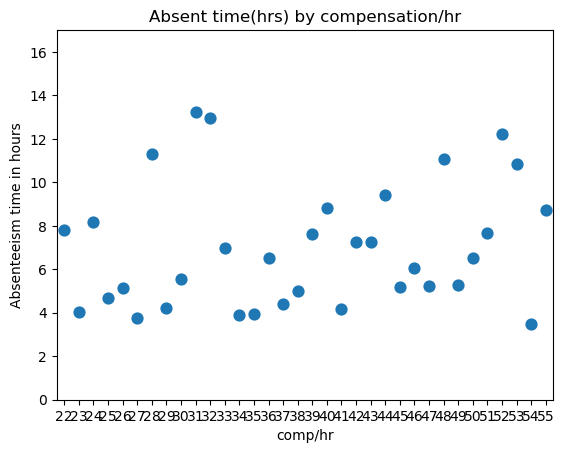

<Figure size 640x480 with 0 Axes>

In [14]:
# Absent time(hrs) by compensation/hr - scatter plot

# Finding outliers
sns.boxplot(data = Final_Absent, x = "comp/hr") # None
sns.boxplot(data = Final_Absent, x = "Absenteeism time in hours") # Outliers from ~ 20
plt.clf()

# Finding outer outlier
seventy_five = Final_Absent["Absenteeism time in hours"].quantile(0.75)
twenty_five = Final_Absent["Absenteeism time in hours"].quantile(0.25)
IQR = seventy_five - twenty_five
outerOutliner = 1.5*IQR + seventy_five # exact 17

# Plotting final
sns.pointplot(data = Final_Absent, x = "comp/hr", y = "Absenteeism time in hours", estimator= np.mean, errorbar= None, linestyles="" )
plt.ylim(0,outerOutliner)
plt.title("Absent time(hrs) by compensation/hr")
plt.show()
plt.clf()

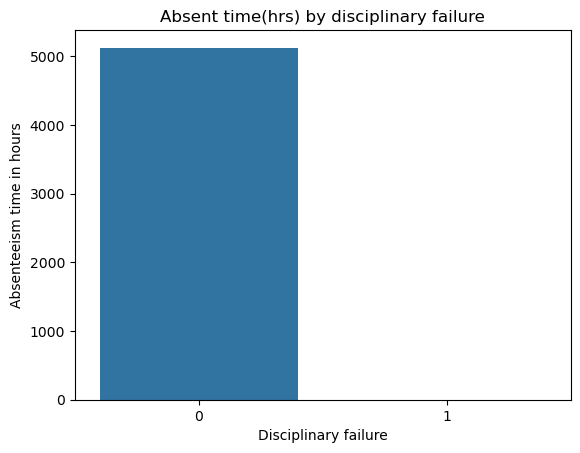

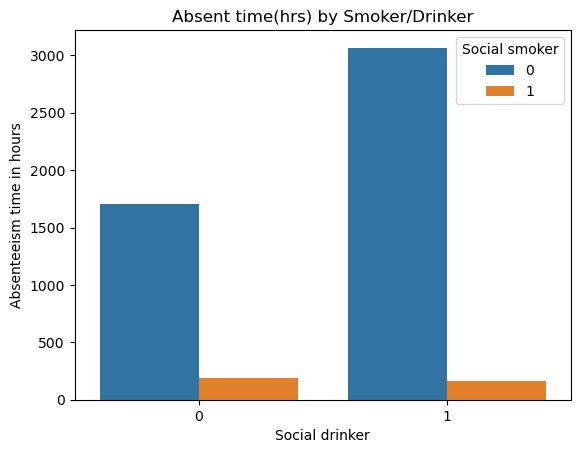

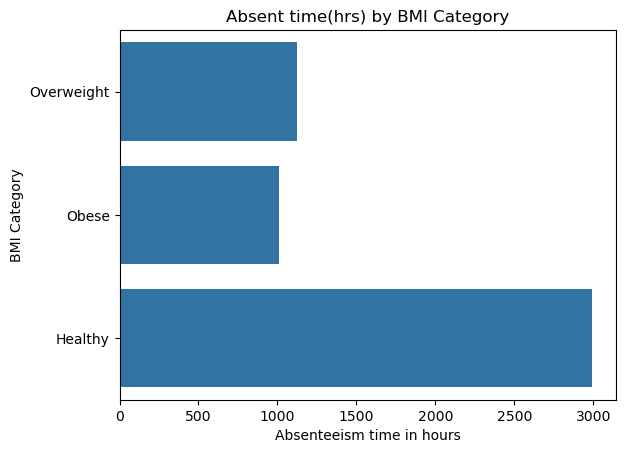

<Figure size 640x480 with 0 Axes>

In [15]:
# Absent time(hrs) by disciplinary failure - column
sns.barplot(data = Final_Absent, x = "Disciplinary failure", y = "Absenteeism time in hours", estimator=np.sum, errorbar=None)
plt.title("Absent time(hrs) by disciplinary failure")
plt.show()
plt.clf()

# Absent time(hrs) by Smoker/Drinker - clustered column
sns.barplot(data = Final_Absent, x = "Social drinker", y = "Absenteeism time in hours", 
            hue= "Social smoker", estimator=np.sum, errorbar=None)
plt.title("Absent time(hrs) by Smoker/Drinker")
plt.show()
plt.clf()

# Absent time(hrs) by BMI Category - bar
sns.barplot(data = Final_Absent, y = "BMI Category", x = "Absenteeism time in hours", estimator=np.sum, errorbar=None,
           orient="h")
plt.title("Absent time(hrs) by BMI Category")
plt.show()
plt.clf()

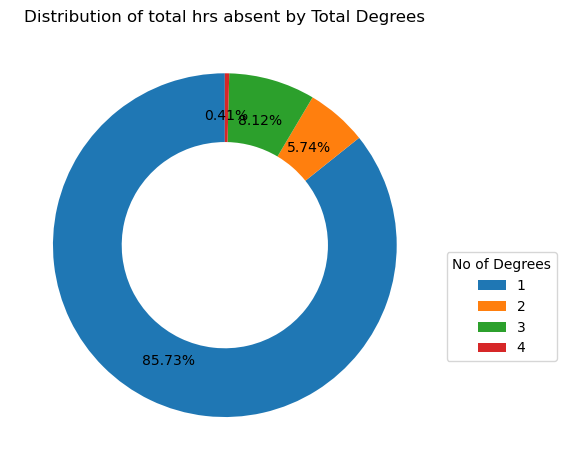

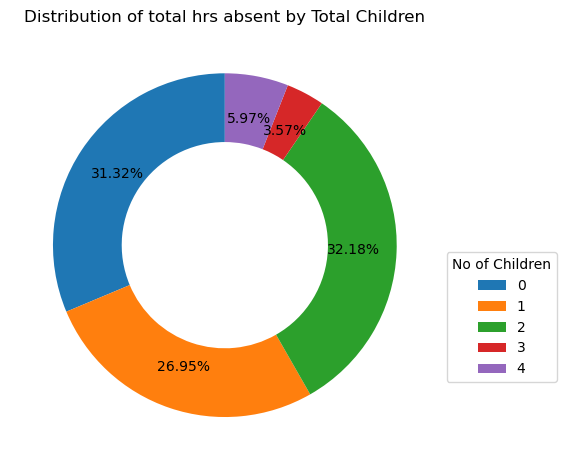

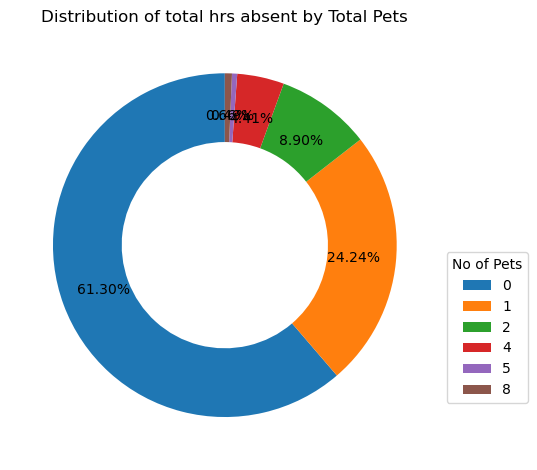

<Figure size 640x480 with 0 Axes>

In [16]:
# Distribution of total hrs absent by degrees - donut
absent_degrees = Final_Absent.groupby("Education")["Absenteeism time in hours"].sum()
plt.pie(absent_degrees, autopct="%1.2f%%", 
        startangle= 90, wedgeprops={"width":0.4},
        pctdistance=0.75, textprops={'fontsize':10, 'color': 'black'})
plt.legend(absent_degrees.index, title = "No of Degrees", loc = "best", bbox_to_anchor = (1, 0.5))
plt.title("Distribution of total hrs absent by Total Degrees")
plt.tight_layout()
plt.show()
plt.clf()

# Distribution of total hrs absent by total children - donut
absent_children = Final_Absent.groupby("Son")["Absenteeism time in hours"].sum()
plt.pie(absent_children, autopct="%1.2f%%", 
        startangle= 90, wedgeprops={"width":0.4},
        pctdistance=0.75, textprops={'fontsize':10, 'color': 'black'})
plt.legend(absent_children.index, title = "No of Children", loc = "best", bbox_to_anchor = (1, 0.5))
plt.title("Distribution of total hrs absent by Total Children")
plt.tight_layout()
plt.show()
plt.clf()

# Distribution of total hrs absent by total pets - donut
absent_pets = Final_Absent.groupby("Pet")["Absenteeism time in hours"].sum()
plt.pie(absent_pets, autopct="%1.2f%%", 
        startangle= 90, wedgeprops={"width":0.4},
        pctdistance=0.75, textprops={'fontsize':10, 'color': 'black'})
plt.legend(absent_pets.index, title = "No of Pets", loc = "best", bbox_to_anchor = (1, 0.5))
plt.title("Distribution of total hrs absent by Total Pets")
plt.tight_layout()
plt.show()
plt.clf()

# Final Insights
1. Non-Smokers are eligible for a wage increase of approx $1433.
2. March sees the highest number of absentees; Thursdays the lowest.
3. Over 50% of employees taking leave are in the healthy BMI range.
4. Significant absent hours come from the 31-34 age group.
5. Medical and dental consultations make up majority of the leaves.
6. There is a slight positive correlation between compensation/hour and absent hours
7. No one who had a disciplinary failure took leave
8. Employees who drink but do not smoke had the highest absent hours.

# Thank you!